# SETUP - Community detection with GraphFrames

## Install packages and dataset - imports

In [15]:
!pip install -q pyspark pandas networkx graphframes matplotlib
!wget https://snap.stanford.edu/data/email-Eu-core.txt.gz
!wget https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz

--2026-10-01 17:51:58--  https://snap.stanford.edu/data/email-Eu-core.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 79754 (78K) [application/x-gzip]
Saving to: ‘email-Eu-core.txt.gz’

email-Eu-core.txt.g 100%[===================>]  77.88K   296KB/s    in 0.3s    

2026-10-01 17:51:59 (296 KB/s) - ‘email-Eu-core.txt.gz’ saved [79754/79754]

--2026-10-01 17:51:59--  https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2663 (2.6K) [application/x-gzip]
Saving to: ‘email-Eu-core-department-labels.txt.gz’

email-Eu-core-depar 100%[===================>]   2.60K  --.-KB/s    in 0s      

2026-10-01 17:51:59 (58.3 MB/

In [16]:
!gzip -d email-Eu-core.txt.gz
!gzip -d email-Eu-core-department-labels.txt.gz

gzip: email-Eu-core.txt already exists; do you wish to overwrite (y or n)? ^C
gzip: email-Eu-core-department-labels.txt already exists; do you wish to overwrite (y or n)? ^C


In [17]:
import os
os.environ["PYSPARK_SUBMIT_ARGS"] = "--packages io.graphframes:graphframes-spark4_2.13:0.12.1 pyspark-shell"

from graphframes import *
from pyspark.sql import SparkSession
from itertools import combinations
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import gzip
import time
import heapq
import glob
from collections import Counter

In [18]:
ss = SparkSession.builder \
    .appName("CD-GF") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

In [19]:
print(f"Spark Version: {ss.version}")

Spark Version: 4.0.4


In [20]:
print(f"Scala Version: {ss._jvm.scala.util.Properties.versionString()}")

Scala Version: version 2.13.16


## Dataset processing

In [21]:
# 1. Carica il file originale e ripulisci
df = pd.read_csv("email-Eu-core.txt", sep=r'\s+', header=None, names=['source', 'target'])
df = df[df['source'] != df['target']]

df['u'] = np.minimum(df['source'], df['target'])
df['v'] = np.maximum(df['source'], df['target'])
df_edges = df.groupby(['u', 'v']).size().reset_index(name='weight')
df_edges = df_edges.rename(columns={'u': 'source', 'v': 'target'})

# 2. Crea il mapping deterministico e contiguo (0 ... N-1)
unique_nodes = sorted(list(set(df_edges['source']).union(set(df_edges['target']))))
node_map = {node: idx for idx, node in enumerate(unique_nodes)}

# Applica il mapping agli archi
df_edges['source'] = df_edges['source'].map(node_map)
df_edges['target'] = df_edges['target'].map(node_map)
df_edges.to_csv('email_graph.csv', index=False)

# 3. Carica la Ground Truth e rimappa coerentemente
df_gt = pd.read_csv("email-Eu-core-department-labels.txt", sep=r'\s+', header=None, names=['node', 'dept'])
# Considera solo i nodi effettivamente presenti nel grafo ed effettua il mapping
df_gt = df_gt[df_gt['node'].isin(node_map)]
df_gt['mapped_node'] = df_gt['node'].map(node_map)

ground_truth = df_gt.groupby('dept')['mapped_node'].apply(lambda x: set(x.tolist())).tolist()

print(f"Grafo 'email_graph.csv' creato con {len(unique_nodes)} nodi e {len(df_edges)} archi.")
print(f"Caricate {len(ground_truth)} comunità da Ground Truth.")

Grafo 'email_graph.csv' creato con 986 nodi e 16064 archi.
Caricate 42 comunità da Ground Truth.


## Functions

In [22]:
# coding: utf-8

__author__      = "Elena-Simona Apostol, Adrian-Cosmin Cojocaru, and Ciprian-Octavian Truică"
__affiliation__ = "National University of Science and Technology Politehnica Bucharest"
__copyright__   = "Copyright 2024"
__license__     = "GNU GPL"
__version__     = "0.1"
__email__       = "ciprian.truica@upb.ro"
__status__      = "Research"

def OLD_get_planted_partition_graph(csv_name="path.csv"):
    # G = nx.planted_partition_graph(5, 30, 0.5, 0.1, seed=42)
    # G = nx.planted_partition_graph(10, 50, 0.5, 0.1, seed=42)
    df = pd.read_csv(csv_name)
    uniq_ids1 = df['source'].unique().tolist()
    uniq_ids2 = df['target'].unique().tolist()
    # print(uniq_ids1)
    # print(uniq_ids2)
    uniq_ids = set(uniq_ids1 + uniq_ids2)
    idx = 0
    remaping = {}
    for elem in uniq_ids:
        remaping[elem] = idx
        df.loc[df['source'] == elem, 'source'] = remaping[elem]
        df.loc[df['target'] == elem, 'target'] = remaping[elem]
        idx += 1
    # print(df['source'].unique())
    Graphtype = nx.Graph()
    G = nx.from_pandas_edgelist(df, edge_attr='weight', create_using=Graphtype)
    return G

def get_planted_partition_graph(csv_name="email_graph.csv"):
    df = pd.read_csv(csv_name)

    # Now dataset already has numeric integer as id
    Graphtype = nx.Graph()
    G = nx.from_pandas_edgelist(df, source='source', target='target', edge_attr='weight', create_using=Graphtype)
    return G

def get_graphframes_planned_partitions(csv_name):
    g = get_planted_partition_graph(csv_name)
    vertices_graphframes = []
    for i in g.nodes:
        vertices_graphframes.append((str(i), i, [i]))

    edges_graphframes = []
    for edge in g.edges:
        try:
            weight = g.get_edge_data(*edge)['weight']
        except:
            weight = 1
        edges_graphframes.append((edge[0], edge[1], "friend", weight))
        edges_graphframes.append((edge[1], edge[0], "friend", weight))
    return g, vertices_graphframes, edges_graphframes

def get_sample_graph(csv_name):
    vertices_columns, edges_columns = ["name", "id", "community"], ["src", "dst", "relationship", "weight"]
    g1, vertices, edges = get_graphframes_planned_partitions(csv_name)
    v = ss.createDataFrame(vertices, vertices_columns)
    e = ss.createDataFrame(edges, edges_columns)
    g = GraphFrame(v, e)
    return g


# k-clicques

def get_cliques_from_motifs(motifs):
    cliques = set()
    for row in motifs:
        current_clique = []
        for x in row:
            if "src" in x:
                current_clique.append(x["src"])
        cliques.add(frozenset(current_clique))

    return list(cliques)

def get_pattern_motif(k):
    ch = 97
    nodes = []
    for i in range(k):
        x = chr(ch+i)
        nodes.append(x)

    pattern = ""
    for (src, dst) in combinations(nodes, 2):
        pattern += r'({})-[{}{}]->({});'.format(src, src, dst, dst)
        pattern += r'({})-[{}{}]->({});'.format(dst, dst, src, src)

    return pattern[:-1]


def get_clique_neighbours(clique, cliques_of):
    neighbour_cliques = set()
    for n in clique:
        for adj_clique in cliques_of[n]:
            if clique != adj_clique:
                neighbour_cliques.add(adj_clique)
    return neighbour_cliques

def run_kcliques(k, g):
    k = k
    pattern = get_pattern_motif(k)

    motifs = g.find(pattern).collect()
    cliques = get_cliques_from_motifs(motifs)
    cliques_of = {}
    for clique in cliques:
        for vertex in clique:
            if vertex not in cliques_of:
                cliques_of[vertex] = []
            cliques_of[vertex].append(clique)

    clique_nodes, clique_edges = [], []
    cliques_graph = nx.Graph()
    cliques_graph.add_nodes_from(cliques)
    for clique in cliques:
        neighbors = get_clique_neighbours(clique, cliques_of)
        for neighbor_clique in neighbors:
            common_nodes = set(clique).intersection(set(neighbor_clique))
            if len(common_nodes) == (k - 1):
                cliques_graph.add_edge(clique, neighbor_clique)


    communities = []
    for component in nx.connected_components(cliques_graph):
       communities.append(list(frozenset.union(*component)))
    for community in communities:
        print(sorted(community))
    return communities

# Fast Greedy & Louvain utils

def get_graph_vertices_list(g):
    vertices = []
    dataframe_vertices = g.vertices.select("id").collect()
    for row in dataframe_vertices:
        vertices.append(row.id)
    return vertices

def get_graph_edges_list(g):
    edges = []
    dataframe_edges = g.edges.select("src","dst","weight").collect()
    for row in dataframe_edges:
        edges.append((row.src, row.dst,row.weight))
    return edges

def get_graph_weights_sum(g):
    dataframe_weights_sum = g.edges.select('weight').groupBy().sum().collect()
    return dataframe_weights_sum[0]["sum(weight)"]

def get_nodes_degrees(g):
    nodes = get_graph_vertices_list(g)
    in_degree = {}
    out_degree = {}
    idx = 0
    for node in nodes:
        out_degree[node] = g.edges.select("weight").where("src=={}".format(node)).groupBy().sum().collect()[0]["sum(weight)"]
        in_degree[node] = g.edges.select("weight").where("dst=={}".format(node)).groupBy().sum().collect()[0]["sum(weight)"]
        if in_degree[node] == None:
            in_degree[node] = 0
        if out_degree[node] == None:
            out_degree[node] = 0
        idx += 1
    return in_degree, out_degree

# Fast Greedy

def store_delta_ij(edge, in_degree, out_degree, m, delta_Q):
    i, j, weight_ij = edge
    ki_in, ki_out, kj_in, kj_out = in_degree[i], out_degree[i], in_degree[j], out_degree[j]
    # delta_Q[(i,j)] = (weight_ij/m) - (in_degree[i] * out_degree[j] + in_degree[j] * out_degree[i])/(2*m)**2
    delta_Q_ij = (weight_ij/m) - ((in_degree[i] * out_degree[j] + in_degree[j] * out_degree[i])/(m**2))
    if not i in delta_Q:
        delta_Q[i] = {j: delta_Q_ij}
    else:
        delta_Q[i][j] = delta_Q_ij

    if not j in delta_Q:
        delta_Q[j] = {i: delta_Q_ij}
    else:
        delta_Q[j][i] = delta_Q_ij

def make_heap(delta_Q, delta_Q_heap):
    for i in delta_Q:
        delta_Q_heap[i]  = []
        for j in delta_Q[i]:
            delta_ij = delta_Q[i][j]
            delta_Q_heap[i].append((-delta_ij, i, j))
        heapq.heapify(delta_Q_heap[i])

def update_heaps(j, k, delta, delta_Q_heap, delta_Q, H, neighbor_flag=False):
    if len(delta_Q_heap[j]) > 0:
        current_peek = delta_Q_heap[j][0]
    else:
        current_peek = None
    delta_Q[j][k] = delta
    if neighbor_flag:
        delta_Q_heap[j] = list(filter(lambda x: not(x[1] == j and x[2] == k), delta_Q_heap[j]))
        heapq.heapify(delta_Q_heap[j])
        heapq.heappush(delta_Q_heap[j], (-delta, j, k))
    else:
        heapq.heappush(delta_Q_heap[j], (-delta, j, k))

    if current_peek is None:
        heapq.heappush(H, delta_Q_heap[j][0])
    elif current_peek != delta_Q_heap[j][0]:
        H.remove(current_peek)
        heapq.heapify(H)
        heapq.heappush(H, delta_Q_heap[j][0])

def remove_from_heaps(i, j, H, delta_Q, delta_Q_heap):
    if len(delta_Q_heap[i]) > 0 and delta_Q_heap[i][0][1] == i and delta_Q_heap[i][0][2] == j:
        i_row_peek = heapq.heappop(delta_Q_heap[i])
        H.remove(i_row_peek)
        heapq.heapify(H)
        if len(delta_Q_heap[i]) >= 1:
            heapq.heappush(H, delta_Q_heap[i][0])
    else:
        delta_Q_heap[i] = list(filter(lambda x: not(x[1] == i and x[2] == j), delta_Q_heap[i]))
        heapq.heapify(delta_Q_heap[i])



def remove_node(i, community, in_degree, out_degree, H, delta_Q, delta_Q_heap):

    # merge node i into community, community aquires its in/out degrees
    in_degree[community] += in_degree[i]
    out_degree[community] += out_degree[i]
    in_degree[i], out_degree[i] = 0, 0

    for j in list(delta_Q[i]):
        delta_Q[j].pop(i)
        if j == community:
            continue
        remove_from_heaps(i, j, H, delta_Q, delta_Q_heap)
        remove_from_heaps(j, i, H, delta_Q, delta_Q_heap)

    delta_Q.pop(i)

def run_graphframes(g):
    m = get_graph_weights_sum(g)
    in_degree, out_degree = get_nodes_degrees(g)
    # print(in_degree, out_degree)
    edges = get_graph_edges_list(g)
    delta_Q, delta_Q_heap = {}, {}
    for edge in edges:
        store_delta_ij(edge, in_degree, out_degree, m, delta_Q)
    make_heap(delta_Q, delta_Q_heap)
    H = []
    for (i, delta) in delta_Q_heap.items():
        H.append(delta[0])
    heapq.heapify(H)

    communities = {i: set([i]) for i in out_degree}
    yield communities.values()
    while True:
        if len(H) < 1:
            break
        delta_ij, i, j = heapq.heappop(H)
        delta_ij *= -1
        yield delta_ij
        heapq.heappop(delta_Q_heap[i])

        # push next biggest priority pair from i row heap into H
        if len(delta_Q_heap[i]) >= 1:
            heapq.heappush(H, delta_Q_heap[i][0])

        # remove (j,i) pair from H(if neccessary) and from j row heap
        if len(delta_Q_heap[j]) >= 1:
            delta_ji, j1, i1 = delta_Q_heap[j][0]
            if i == i1 and j == j1:
                H = list(filter(lambda x: not(x[1] == j1 and x[2] == i1), H))
                heapq.heapify(H)
                heapq.heappop(delta_Q_heap[j])
                #  push next biggest priority pair from j row heap into H
                if len(delta_Q_heap[j]) >= 1:
                    heapq.heappush(H, delta_Q_heap[j][0])
            else:
                delta_Q_heap[j] = list(filter(lambda x: x[1] != j and x[2] != i, delta_Q_heap[j]))
                heapq.heapify(delta_Q_heap[j])

        i_adjacent_nodes = set(delta_Q[i].keys())
        j_adjacent_nodes = set(delta_Q[j].keys())
        disjoint_neigbors = i_adjacent_nodes.union(j_adjacent_nodes)

        communities[j].update(communities[i])
        communities.pop(i)

        for k in disjoint_neigbors:
            if k == i or k == j:
                continue
            elif k in i_adjacent_nodes and k in j_adjacent_nodes:
                delta_jk = delta_Q[i][k] + delta_Q[j][k]
            elif k in i_adjacent_nodes:
                delta_jk = delta_Q[i][k] - (in_degree[j] * out_degree[k] + in_degree[k] * out_degree[j])/(m**2)
            elif k in j_adjacent_nodes:
                delta_jk = delta_Q[j][k] - (in_degree[i] * out_degree[k] + in_degree[k] * out_degree[i])/(m**2)
            update_heaps(j, k, delta_jk, delta_Q_heap, delta_Q, H, k in j_adjacent_nodes)
            update_heaps(k, j, delta_jk, delta_Q_heap, delta_Q, H, k in j_adjacent_nodes)
        remove_node(i, j, in_degree, out_degree, H, delta_Q, delta_Q_heap)

        yield communities.values()

def run_fastgreedy(g):
    community_gen = run_graphframes(g)

    cutoff = 1
    communities = next(community_gen)

    while len(communities) > 1:
        dq = next(community_gen)
        if dq < 0:
            break
        communities = next(community_gen)

    for community in communities:
        print(sorted(community))

    return communities


# Louvain

def get_degree_to_adjacent_communities(g, node, community_of):
    degree = {}
    neighbors = list(map(lambda x: (x.dst,x.weight), g.edges.select("dst", "weight").where("src=={}".format(node)).collect()))
    for (neighbor, weight) in neighbors:
        adjacent_community = community_of[neighbor]
        if adjacent_community not in degree:
            degree[adjacent_community] = 0
        degree[adjacent_community] += weight
    return degree

def get_global_community(g, node):
    enclosed_nodes = set(list(g.vertices.select("community").where("id=={}".format(node)).collect()[0].community))
    return enclosed_nodes

def calc_modularity(g, partition, m):
    m = get_graph_weights_sum(g)
    modularity = 0
    in_degree, out_degree = get_nodes_degrees(g)
    edges = get_graph_edges_list(g)
    community_of = {}
    for idx, part in enumerate(partition):
        for node in part:
            community_of[node] = idx
    for edge in edges:
        src, dst = edge[0], edge[1]
        community_src, community_dst = community_of[src], community_of[dst]
        if community_src != community_dst:
            continue
        weight = edge[2]
        modularity += (weight/2*m) - (in_degree[src]*out_degree[dst])/(2*m**2)
    return modularity

def first_phase_louvain(g, global_partition, m, gamma):
    community_of = {node: idx for idx, node in enumerate(get_graph_vertices_list(g))}
    nodes = get_graph_vertices_list(g)
    new_partition = [set() for node in nodes]
    (in_degree, out_degree), (community_in, community_out) = get_nodes_degrees(g), get_nodes_degrees(g)
    while True:
        stop = True
        for node in nodes:
            chosen_comunity = community_of[node]
            max_improvement = 0
            community_in[chosen_comunity] -= in_degree[node]
            community_out[chosen_comunity] -= out_degree[node]
            degree_to_adj_communities = get_degree_to_adjacent_communities(g, node, community_of)
            for (adjacent_community, adjacent_degree) in degree_to_adj_communities.items():
                improvement = (adjacent_degree - gamma * (in_degree[node] * community_out[adjacent_community] + out_degree[node] * community_in[adjacent_community])/m)
                if improvement > max_improvement:
                    max_improvement = improvement
                    chosen_comunity = adjacent_community
            community_in[chosen_comunity] += in_degree[node]
            community_out[chosen_comunity] += out_degree[node]
            if chosen_comunity != community_of[node]:
                community_of[node] = chosen_comunity
                stop = False
        if stop:
            break
    for node, community in community_of.items():
        new_partition[community].add(node)
        global_community = get_global_community(g, node)
        global_partition[node].difference_update(global_community)
        global_partition[community].update(global_community)
    new_partition = list(filter(lambda x: x != set(), new_partition))
    global_partition = list(filter(lambda x: x != set(), global_partition))

    return global_partition, new_partition, stop

def second_phase_louvain(g, new_partition):
    community_of = {}
    vertices_columns = ["name", "id", "community"]
    new_vertices = []
    for idx, partition in enumerate(new_partition):
        enclosed_nodes = []
        for node in partition:
            community_of[node] = idx
            sub_nodes = g.vertices.select("community").where("id=={}".format(node)).collect()[0].community
            enclosed_nodes += sub_nodes
        new_vertices.append((str(idx), idx, enclosed_nodes))

    edges = get_graph_edges_list(g)
    weights_between_communities = {}
    for edge in edges:
        src, dst, weight = edge[0], edge[1], edge[2]
        community_src, community_dst = community_of[src], community_of[dst]
        if not (community_src, community_dst) in weights_between_communities:
            weights_between_communities[(community_src, community_dst)] = 0
        weights_between_communities[(community_src, community_dst)] += weight

    new_edges = []
    edges_columns = ["src", "dst", "relationship", "weight"]
    for k, v in weights_between_communities.items():
        new_edges.append((k[0], k[1], "friend", v))

    v = ss.createDataFrame(new_vertices, vertices_columns)
    e = ss.createDataFrame(new_edges, edges_columns)
    new_g = GraphFrame(v, e)
    return new_g

def run_louvain(g, gamma=0.05):
    m = get_graph_weights_sum(g)
    communities = [{node} for node in get_graph_vertices_list(g)]
    current_modularity = calc_modularity(g, communities, m)
    threshold=0.0000001
    iteration = 0
    while True:
        communities, next_partition, stop = first_phase_louvain(g, communities, m, gamma)
        if stop:
            break

        new_mod = calc_modularity(g, next_partition, m)
        if new_mod - current_modularity <= threshold:
            break

        current_modularity = new_mod
        g = second_phase_louvain(g, next_partition)
        iteration += 1
    print(iteration)
    for community in communities:
        print(sorted(community))
    return communities

# Comminity Detection

In [23]:
path = 'email_graph.csv'
g = get_sample_graph(path)

/usr/local/lib/python3.13/dist-packages/pyspark/sql/classic/dataframe.py:146: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


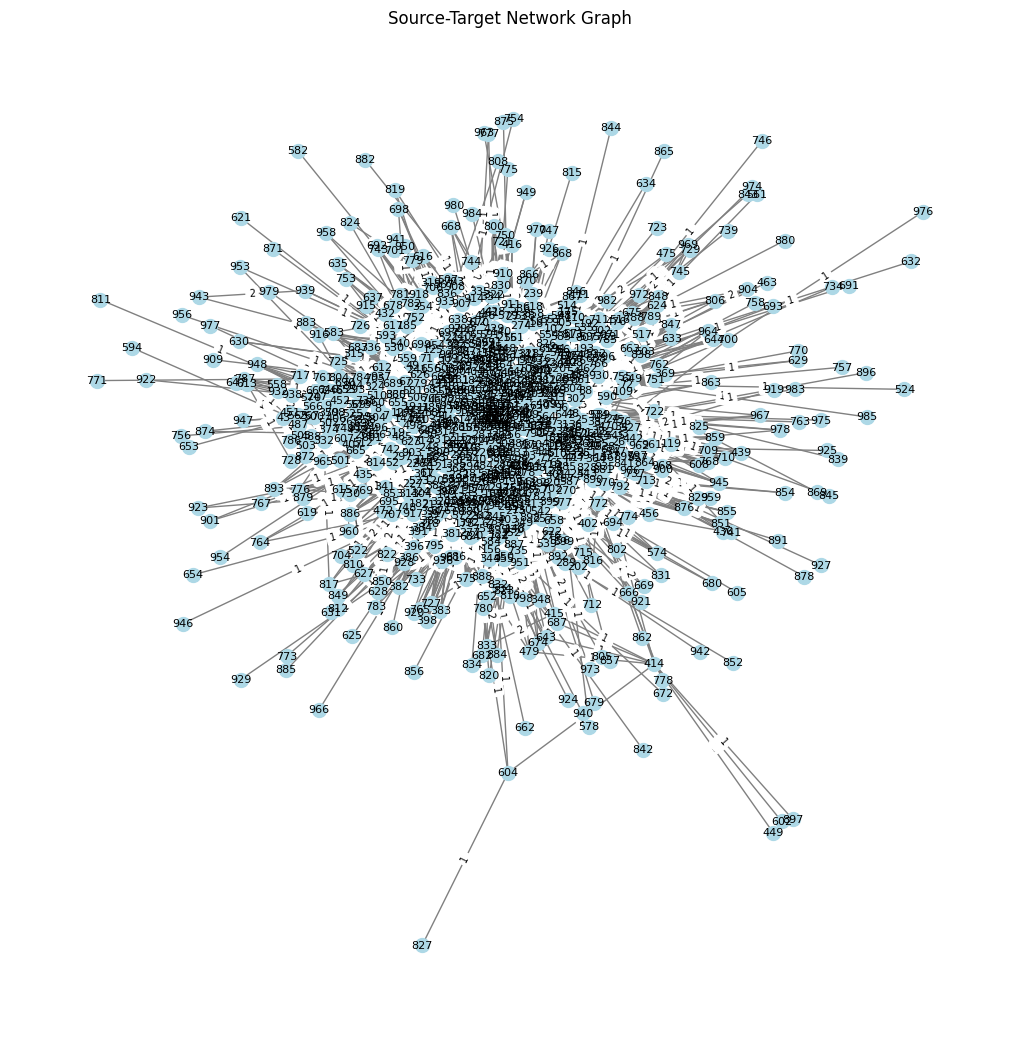

In [24]:
df = pd.read_csv(path)

# 2. Build the graph object
# By default, this creates an undirected graph. Use create_using=nx.DiGraph() for a directed graph.
G = nx.from_pandas_edgelist(df, source='source', target='target', edge_attr='weight')

# 3. Configure the plot layout
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=0.15, seed=42) # k adjusts node spacing

# 4. Draw the nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        edge_color='gray', node_size=100, font_size=8)

# 5. Add the weight labels to the edges
edge_weights = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_weights, font_size=7)

plt.title("Source-Target Network Graph")
plt.show()

## K-Cliques

In [ ]:
t1 = time.time()
comms_kcliques = run_kcliques(3, g)
print("K-Cliques Execution Time:", time.time() - t1)

/usr/local/lib/python3.13/dist-packages/pyspark/sql/classic/dataframe.py:128: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

## Fast Greedy

In [ ]:
t1 = time.time()
comms_fg = run_fastgreedy(g)
print("FastGreedy Execution Time:", time.time() - t1)

[166, 230, 282, 366, 373, 559, 595, 728, 879, 931]
[7, 8, 9, 11, 12, 19, 43, 44, 141, 161, 213, 246, 247, 264, 265, 266, 267, 293, 324, 332, 358, 359, 360, 362, 374, 406, 407, 421, 430, 441, 451, 452, 466, 487, 488, 496, 498, 499, 500, 501, 502, 503, 504, 505, 506, 510, 525, 529, 530, 555, 558, 565, 566, 569, 570, 573, 601, 607, 646, 655, 660, 665, 667, 689, 690, 696, 708, 717, 725, 738, 749, 761, 786, 787, 804, 808, 811, 814, 837, 874, 893, 894, 903, 932, 937, 938, 948, 952, 953, 954, 956, 977]
[14, 41, 52, 53, 60, 61, 65, 94, 95, 103, 104, 122, 130, 148, 149, 150, 156, 157, 167, 168, 172, 176, 177, 178, 179, 180, 181, 182, 191, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 214, 219, 231, 232, 250, 257, 262, 275, 276, 277, 278, 280, 284, 289, 291, 292, 294, 295, 296, 320, 321, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 368, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 401, 403, 413, 42

## Louvain

In [ ]:
t1 = time.time()
comms_louvain = run_louvain(g)
print("Louvain Execution Time:", time.time() - t1)

0
[5]
[6]
[17]
[18]
[64]
[65]
[73]
[74]
[88]
[101]
[103]
[120]
[146]
[148]
[166]
[177]
[178]
[215]
[218]
[221]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199

## Louvain

In [ ]:
t1 = time.time()
comms_louvain = run_louvain(g, gamma = 1 )
print("Louvain Execution Time:", time.time() - t1)

0
[5]
[6]
[17]
[18]
[64]
[65]
[73]
[74]
[88]
[101]
[103]
[120]
[146]
[148]
[166]
[177]
[178]
[215]
[218]
[221]
[0, 1, 17, 18, 73, 74, 85, 120, 146, 177, 215, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 248, 268, 297, 307, 309, 310, 311, 312, 313, 314, 315, 316, 317, 330, 331, 341, 366, 459, 468, 519, 537, 560, 612, 613, 628, 647, 681, 685, 686, 705, 714, 730, 740, 742, 748, 758, 764, 771, 776, 853, 886, 960, 983]
[223]
[226]
[238]
[248]
[250]
[266]
[268]
[283]
[297]
[309]
[313]
[316]
[368]
[377]
[380]
[459]
[498]
[560]
[580]
[720]
[21]
[52]
[82]
[84]
[85]
[106]
[121]
[127]
[128]
[142]
[147]
[155]
[187]
[189]
[199]
[224]
[225]
[232]
[254]
[255]
[280]
[284]
[310]
[317]
[351]
[450]
[495]
[537]
[548]
[549]
[568]
[615]
[639]
[714]
[960]
[2]
[3]
[4]
[13]
[54]
[55]
[56]
[57]
[58]
[59]
[62]
[63]
[86]
[89]
[96]
[102]
[107]
[114]
[126]
[131]
[132]
[137]
[138]
[140]
[158]
[160]
[162]
[164]
[174]
[192]
[193]
[2, 3, 4, 6, 54, 55, 56, 57, 58, 59, 63, 88, 89, 102, 126, 131, 132, 137, 138, 